# DMRG Time dependent variation principle (TDVP)

Edited by [Min Long](https://quantummc.xyz/members/min-long/), December.2023.

Modified by [Hongyu Chen](https://quantummc.xyz/hongyuchern/) in July 2026.

Modified by [Hankun Zhang](https://quantummc.xyz/members/zhang-hankun/) in September 2026.

This notebook contains the dynamic properties of Heisenberg chian in the formalism of matric product state(MPS).
In the previous notebook, we evaluate the time evolution operator $e^{-i\hat{H}t}|\psi\rangle$, descretize it by Trottoer decomposition and perform the evolution per time step.

However, there is another one-step solution which called TDVP that can evolve MPS the for large t efficiently without any trotter error(This is extremely efficient when study low temperature behavior of the system via imaginary time evolution)

The idea is to construct a tangent space projector and solve the Schodinger equation in tangent space
$$
i\hbar \frac{\partial |\psi\rangle }{\partial t } = \hat{P}\hat{H}|\psi\rangle
$$

The initial state $|\psi\rangle$ is prepared and written in MPS form. I first calculate the ground state. Then introduce the concept of MPS manifold, then I show how to construct tangent space projector, finally I solve the Schodinger equation  

First we prepare the groudstate, this process is copied from the file "DMRG_MPS"

For the reference, reader can refer to the original paper of Jutho Haegeman [\[ref\]](https://arxiv.org/abs/1408.5056)

## 1. Ground state calculation [\[DMRG_MPS\]](https://colab.research.google.com/github/DavidGoing/DMRG/blob/main/DMRG_MPS.ipynb)

In [ ]:
import numpy as np
import scipy
import scipy.sparse.linalg
import scipy.sparse as sparse
from time import perf_counter
import numpy.linalg as npla
import matplotlib.pyplot as plt
import copy
import math


## initial E and F matrices for the left and right vacuum states
def initial_E(W):
    E = np.zeros((W.shape[0], 1, 1))
    E[0] = 1
    return E


def initial_F(W):
    F = np.zeros((W.shape[1], 1, 1))
    F[-1] = 1
    return F


def contract_from_right(W, A, F, B):
    # the einsum function doesn't appear to optimize the contractions properly,
    # so we split it into individual summations in the optimal order
    # return np.einsum("abst,sij,bjl,tkl->aik",W,A,F,B, optimize=True)
    Temp = np.einsum("sij,bjl->sbil", A, F)
    Temp = np.einsum("sbil,abst->tail", Temp, W)
    return np.einsum("tail,tkl->aik", Temp, B.conjugate())


def contract_from_left(W, A, E, B):
    # the einsum function doesn't appear to optimize the contractions properly,
    # so we split it into individual summations in the optimal order
    # return np.einsum("abst,sij,aik,tkl->bjl",W,A,E,B, optimize=True)
    Temp = np.einsum("sij,aik->sajk", A, E)
    Temp = np.einsum("sajk,abst->tbjk", Temp, W)
    return np.einsum("tbjk,tkl->bjl", Temp, B.conjugate())


# construct the F-matrices for all sites except the first
def construct_F(Alist, MPO, Blist):
    F = [initial_F(MPO[-1])]

    for i in range(len(MPO) - 1, 0, -1):
        F.append(contract_from_right(MPO[i], Alist[i], F[-1], Blist[i]))
    return F


def construct_E(Alist, MPO, Blist):
    return [initial_E(MPO[0])]


# 2-1 coarse-graining of two site MPO into one site
def coarse_grain_MPO(W, X):
    return np.reshape(np.einsum("abst,bcuv->acsutv", W, X),
                      [W.shape[0], X.shape[1],
                       W.shape[2] * X.shape[2],
                       W.shape[3] * X.shape[3]])


def product_W(W1, W2):
    return np.reshape(np.einsum("abst,cdtu->acbdsu", W1, W2), [W1.shape[0] * W2.shape[0],
                                                               W1.shape[1] * W2.shape[1],
                                                               W1.shape[2], W2.shape[3]])


def product_MPO(M1, M2):
    assert len(M1) == len(M2)
    Result = []
    for i in range(0, len(M1)):
        Result.append(product_W(M1[i], M2[i]))
    return Result


# 2-1 coarse-graining of two-site MPS into one site
def coarse_grain_MPS(A, B):
    return np.reshape(np.einsum("sij,tjk->stik", A, B),
                      [A.shape[0] * B.shape[0], A.shape[1], B.shape[2]])


def fine_grain_MPS(A, dims):
    assert A.shape[0] == dims[0] * dims[1]
    Theta = np.transpose(np.reshape(A, dims + [A.shape[1], A.shape[2]]),
                         (0, 2, 1, 3))
    M = np.reshape(Theta, (dims[0] * A.shape[1], dims[1] * A.shape[2]))
    U, S, V = np.linalg.svd(M, full_matrices=0)
    U = np.reshape(U, (dims[0], A.shape[1], -1))
    V = np.transpose(np.reshape(V, (-1, dims[1], A.shape[2])), (1, 0, 2))
    # assert U is left-orthogonal
    # assert V is right-orthogonal
    # print(np.dot(V[0],np.transpose(V[0])) + np.dot(V[1],np.transpose(V[1])))
    return U, S, V


def truncate_MPS(U, S, V, m):
    m = min(len(S), m)
    trunc = np.sum(S[m:])
    S = S[0:m]
    U = U[:, :, 0:m]
    V = V[:, 0:m, :]
    return U, S, V, trunc, m


def Expectation(AList, MPO, BList):
    E = [[[1]]]
    for i in range(0, len(MPO)):
        E = contract_from_left(MPO[i], AList[i], E, BList[i])
    return E[0][0][0]


class HamiltonianMultiply(sparse.linalg.LinearOperator):
    def __init__(self, E, W, F):
        self.E = E
        self.W = W
        self.F = F
        self.dtype = np.dtype('d')
        self.req_shape = [W.shape[2], E.shape[1], F.shape[1]]
        self.size = self.req_shape[0] * self.req_shape[1] * self.req_shape[2]
        self.shape = [self.size, self.size]

    def _matvec(self, A):
        # the einsum function doesn't appear to optimize the contractions properly,
        # so we split it into individual summations in the optimal order
        # R = np.einsum("aij,sik,abst,bkl->tjl",self.E,np.reshape(A, self.req_shape),
        #              self.W,self.F, optimize=True)
        R = np.einsum("aij,sik->ajsk", self.E, np.reshape(A, self.req_shape))
        R = np.einsum("ajsk,abst->bjtk", R, self.W)
        R = np.einsum("bjtk,bkl->tjl", R, self.F)
        return np.reshape(R, -1)


## optimize a single site given the MPO matrix W, and tensors E,F
def optimize_site(A, W, E, F):
    H = HamiltonianMultiply(E, W, F)
    # we choose tol=1E-8 here, which is OK for small calculations.
    # to bemore robust, we should take the tol -> 0 towards the end
    # of the calculation.
    E, V = sparse.linalg.eigsh(H, 1, v0=A, which='SA', tol=1E-8)
    return (E[0], np.reshape(V[:, 0], H.req_shape))


def optimize_two_sites(A, B, W1, W2, E, F, m, dir):
    W = coarse_grain_MPO(W1, W2)
    AA = coarse_grain_MPS(A, B)
    H = HamiltonianMultiply(E, W, F)
    E, V = sparse.linalg.eigsh(H, 1, v0=AA, which='SA')
    AA = np.reshape(V[:, 0], H.req_shape)
    A, S, B = fine_grain_MPS(AA, [A.shape[0], B.shape[0]])
    A, S, B, trunc, m = truncate_MPS(A, S, B, m)
    if (dir == 'right'):
        B = np.einsum("ij,sjk->sik", np.diag(S), B)
    else:
        assert dir == 'left'
        A = np.einsum("sij,jk->sik", A, np.diag(S))
    return E[0], A, B, trunc, m
def two_site_dmrg(MPS, MPO, m, sweeps):
    E = construct_E(MPS, MPO, MPS)
    F = construct_F(MPS, MPO, MPS)
    F.pop()
    for sweep in range(0, int(sweeps / 2)):
        for i in range(0, len(MPS) - 2):
            Energy, MPS[i], MPS[i + 1], trunc, states = optimize_two_sites(MPS[i], MPS[i + 1],
                                                                           MPO[i], MPO[i + 1],
                                                                           E[-1], F[-1], m, 'right')
            print("Sweep {:} Sites {:},{:}    Energy {:16.12f}    States {:4} Truncation {:16.12f}"
                  .format(sweep * 2 + 1, i, i + 1, Energy, states, trunc))
            E.append(contract_from_left(MPO[i], MPS[i], E[-1], MPS[i]))
            F.pop();
        for i in range(len(MPS) - 2, 0, -1):
            Energy, MPS[i], MPS[i + 1], trunc, states = optimize_two_sites(MPS[i], MPS[i + 1],
                                                                           MPO[i], MPO[i + 1],
                                                                           E[-1], F[-1], m, 'left')
            print("Sweep {} Sites {},{}    Energy {:16.12f}    States {:4} Truncation {:16.12f}"

                  .format(sweep * 2 + 2, i, i + 1, Energy, states, trunc))
            F.append(contract_from_right(MPO[i + 1], MPS[i + 1], F[-1], MPS[i + 1]))
            E.pop();
    return MPS

d_list = [2, 3]
N = 32  # number of sites
D = 10

def build_spin_model(d, N):
    InitialA1 = np.zeros((d, 1, 1))
    InitialA1[0, 0, 0] = 1
    InitialA2 = np.zeros((d, 1, 1))
    InitialA2[d - 1, 0, 0] = 1

    ## initial state |01010101>
    MPS = [InitialA1, InitialA2] * int(N / 2)
    if N%2 != 0 :
        MPS = MPS + [InitialA1]

    ## Local operators
    I = np.identity(d)
    Z = np.zeros((d, d))
    Sz = np.zeros((d, d))
    Sp = np.zeros((d, d))
    Sm = np.zeros((d, d))

    Sz_list = []

    for i in range(d):
          Sz_list.append(d/2 - i -1/2)

    Sz = np.diag(Sz_list)
    Sz = Sz.astype('float64')
    for i in range(d-1):
        Sp[i+1,i] = np.sqrt(d-1)
    for i in range(d-1):
        Sm[i,i+1] = np.sqrt(d-1)
    print('Spin chain with Spin: {}'.format((d-1)/2))
    print('=============\n Sz matrix form: ')
    print(Sz)
    print('=============\n S+ matrix form: ')
    print(Sp)
    print('=============\n S- matrix form: ')
    print(Sm)
    return MPS, I, Z, Sz, Sp, Sm

runs = {}
for d in d_list:
    print('\n========== d = {}, S = {} =========='.format(d, (d - 1) / 2))
    MPS, I, Z, Sz, Sp, Sm = build_spin_model(d, N)
    ## Hamiltonian MPO
    W = np.array([[I, Sz, 0.5 * Sp, 0.5 * Sm, Z],
                  [Z, Z, Z, Z, Sz],
                  [Z, Z, Z, Z, Sm],
                  [Z, Z, Z, Z, Sp],
                  [Z, Z, Z, Z, I]])

    Wfirst = np.array([[I, Sz, 0.5 * Sp, 0.5 * Sm, Z]])

    Wlast = np.array([[Z], [Sz], [Sm], [Sp], [I]])

    # the complete MPO
    MPO = [Wfirst] + ([W] * (N - 2)) + [Wlast]

    HamSquared = product_MPO(MPO, MPO)

    # 8 sweeps with m=10 states
    Gs = two_site_dmrg(MPS, MPO, D, 8)

    Energy = Expectation(Gs, MPO, Gs)
    print("Final energy expectation value {}".format(Energy))

    H2 = Expectation(Gs, HamSquared, Gs)
    print("variance = {:16.12f}".format(H2 - Energy * Energy))
    runs[d] = {
        'Gs': Gs,
        'Sz': Sz,
        'Sp': Sp,
        'Sm': Sm,
        'Energy': Energy,
        'MPO': MPO,
    }



========== d = 2, S = 0.5 ==========
Spin chain with total Spin: 0.5
 Sz matrix form: 
[[ 0.5  0. ]
 [ 0.  -0.5]]
 S+ matrix form: 
[[0. 0.]
 [1. 0.]]
 S- matrix form: 
[[0. 1.]
 [0. 0.]]
Sweep 1 Sites 0,1    Energy  -8.059016994375    States    2 Truncation   0.000000000000
Sweep 1 Sites 1,2    Energy  -8.189692620786    States    2 Truncation   0.000000000000
Sweep 1 Sites 2,3    Energy  -8.395800958670    States    2 Truncation   0.000000000000
Sweep 1 Sites 3,4    Energy  -8.560586239348    States    2 Truncation   0.000000000000
Sweep 1 Sites 4,5    Energy  -8.743669962857    States    2 Truncation   0.000000000000
Sweep 1 Sites 5,6    Energy  -8.917602338044    States    2 Truncation   0.000000000000
Sweep 1 Sites 6,7    Energy  -9.095754582728    States    2 Truncation   0.000000000000
Sweep 1 Sites 7,8    Energy  -9.271867353000    States    2 Truncation   0.000000000000
Sweep 1 Sites 8,9    Energy  -9.448938381096    States    2 Truncation   0.000000000000
Sweep 1 Sites 9,10 

## 2. Measurement, transfer of singular value and benchmark [\[the same with TEBD spin-1/2\]](https://colab.research.google.com/github/DavidGoing/DMRG/blob/main/DMRG_TEBD.ipynb)

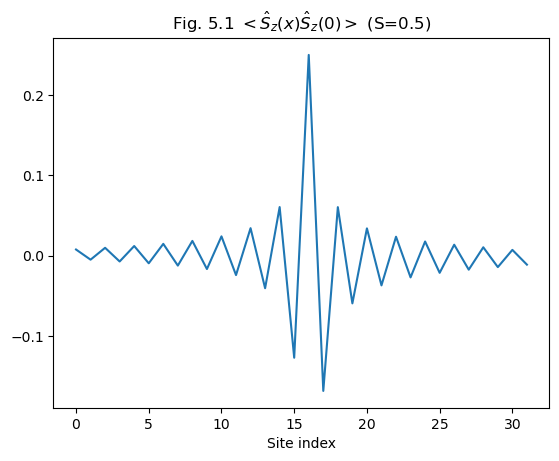

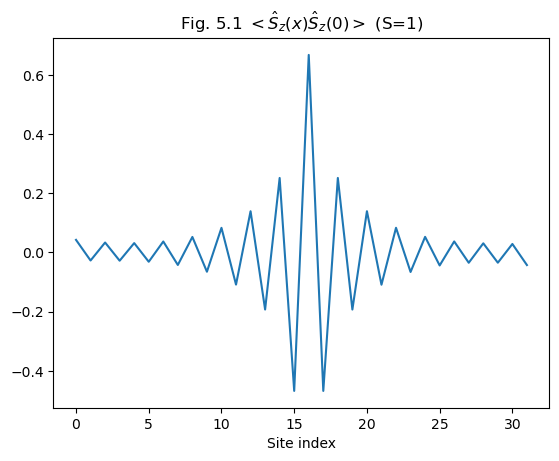


========== prepare d = 2, S = 0.5 ==========
Normalizatin check of Ground state 1.0000000000000009

========== prepare d = 3, S = 1.0 ==========
Normalizatin check of Ground state 1.000000000000002


In [ ]:
def state_overlap(Co_List,Contro_List):
    R = [[1]]
    for i in range(0, len(Co_List)):
        R = np.einsum("ik,sij->skj",R,Co_List[i])
        R = np.einsum("skj,skl->jl",R,Contro_List[i].conjugate())
    return R[0][0]

# def multi_site_measurement(MPS1,MPS2,op_list,pos_list):
#     idx = np.argsort(pos_list)
#     pos_list = np.array(pos_list)[idx]
#     op_list = np.array(op_list)[idx]
#     expectation = [[1]]
#     # print(op_list,pos_list)
#     assert len(op_list) == len(pos_list)
#     for j in range(0, pos_list[0]):
#         expectation = np.einsum("ik,sij->skj", expectation, MPS1[j])
#         expectation = np.einsum("skj,skl->jl",  expectation,MPS2[j].conjugate())
#     expectation = np.einsum('ik,sij,st,tkl->jl', expectation, MPS1[pos_list[0]], op_list[0], MPS2[pos_list[0]].conjugate())
#     for i in range(len(op_list)-1):
#         for j in range(pos_list[i]+1,pos_list[i+1]):
#             expectation = np.einsum("ik,sij->skj", expectation, MPS1[j])
#             expectation = np.einsum("skj,skl->jl", expectation,MPS2[j].conjugate())
#         expectation = np.einsum('ik,sij,st,tkl->jl', expectation, MPS1[pos_list[i+1]], op_list[i+1], MPS2[pos_list[i+1]].conjugate())
#     for j in range(pos_list[-1]+1,len(MPS1)):
#         expectation = np.einsum("ik,sij->skj", expectation, MPS1[j])
#         expectation = np.einsum("skj,skl->jl", expectation,MPS2[j].conjugate())
#     return expectation[0][0]

def multi_site_measurement(MPS1, MPS2, op_list, pos_list):
    idx = np.argsort(pos_list)
    pos_list = np.array(pos_list)[idx]
    op_list = np.array(op_list)[idx]
    assert len(op_list) == len(pos_list)

    expectation = [[1]]
    k = 0
    for j in range(len(MPS1)):
        if k < len(pos_list) and j == pos_list[k]:
            expectation = np.einsum(
                'ik,sij,st,tkl->jl',
                expectation, MPS1[j], op_list[k], MPS2[j].conjugate(),
                optimize=True,
            )
            k += 1
        else:
            expectation = np.einsum(
                'ik,sij,skl->jl',
                expectation, MPS1[j], MPS2[j].conjugate(),
                optimize=True,
            )
    return expectation[0][0]

def plot_Sz_correlation_MPS(MPS_in):
    Sz_correlation = []
    for i in range(N):
        if i != N//2:
            Sz_correlation.append(multi_site_measurement(MPS_in,Gs,[Sz,Sz],[i,N//2]))
        else:
            Sz_correlation.append(multi_site_measurement(MPS_in, Gs, [Sz@Sz], [i]))
    plt.plot(Sz_correlation)
    plt.title(r"Fig. 5.1 $<\hat{S}_z(x)\hat{S}_z(0)>$ (S=%g)" % ((d - 1) / 2))
    plt.xlabel("Site index")
    # plt.savefig("temp")
    plt.show()
    # plt.savefig("Sz_correlation_measurement_tdvp")
    plt.close()
for d in d_list:
    Gs = runs[d]["Gs"]
    Sz = runs[d]["Sz"]
    plot_Sz_correlation_MPS(Gs)

# quit()

def move_mix_site(start ,end , mix_MPS ,bond_dim):
    if end > start:
        move_dir = 'r'
        for i in range(start,end,1):
            M1 = mix_MPS[i]
            M_mat = np.reshape(M1,(M1.shape[0]*M1.shape[1],M1.shape[2]))
            A, S, B = np.linalg.svd(M_mat, full_matrices=0)
            trunc_dim = min(bond_dim,len(S))
            A = A[:,0:trunc_dim]
            S = S[0:trunc_dim]
            B = B[0:trunc_dim,:]
            # print(npla.norm(A@np.diag(S)@B-M_mat))
            trunc = np.sum(S[trunc_dim:])
            A = np.reshape(A,(M1.shape[0],M1.shape[1],-1))
            # print("Truncation error in moving from site {} to {} : {}".format(i,i+1,trunc))
            if trunc > 1e-10:
                print("Truncation warning: {}".format(trunc))
            B = np.diag(S)@B
            mix_MPS[i] =  A
            mix_MPS[i+1] = np.einsum("ij,sjk->sik",B,mix_MPS[i+1])
    if end < start:
        move_dir = 'l'
        for i in range(start,end,-1):
            M1 = mix_MPS[i]
            M_mat = np.reshape(M1.transpose(1,0,2), (M1.shape[1], M1.shape[0] * M1.shape[2]))
            A, S, B = np.linalg.svd(M_mat, full_matrices=0)
            trunc_dim = min(bond_dim, len(S))
            A = A[:, 0:trunc_dim]
            S = S[0:trunc_dim]
            B = B[0:trunc_dim, :]
            # print(npla.norm(A @ np.diag(S) @ B - M_mat))
            trunc = np.sum(S[trunc_dim:])
            B = np.reshape(B, (-1,M1.shape[0], M1.shape[2])).transpose(1,0,2)
            # print("Truncation error in moving from site {} to {} : {}".format(i, i + 1, trunc))
            if trunc > 1e-10:
                print("Truncation warning: {}".format(trunc))
            A = A@np.diag(S)
            mix_MPS[i] = B
            mix_MPS[i - 1] = np.einsum("sjk,kl->sjl", mix_MPS[i-1], A)
    if "move_dir" not in locals():
        raise Exception("Not standard input form, Nothing happend")
    return mix_MPS

def check_othogonal(MPS):
    infor_string = []
    for ten in MPS:
        matl = np.einsum("sij,sik->jk",ten,ten)
        matr = np.einsum("sij,slj->il",ten,ten)
        dim = matl.shape[0]
        Il = np.identity(dim)
        Ir = np.identity(matr.shape[0])
        if npla.norm(matl-Il)<1e-10:
            infor_string.append('A')
        if npla.norm(matr-Ir)<1e-10:
            infor_string.append('B')
        if not(npla.norm(matl-Il)<1e-10 or npla.norm(matr-Ir)<1e-10):
            infor_string.append('M')
    return ' '.join(infor_string)


tau = 0.2
time_slice = 50

def orthogonize(M, bond_dim):
    M1 = copy.deepcopy(M)
    M_mat = np.reshape(M1, (M1.shape[0] * M1.shape[1], M1.shape[2]))
    A, S, B = np.linalg.svd(M_mat, full_matrices=0)
    trunc_dim = min(bond_dim, len(S))
    A = A[:, 0:trunc_dim]
    S = S[0:trunc_dim]
    B = B[0:trunc_dim, :]
    S = np.array(S) / np.sqrt(sum([abs(item) ** 2 for item in S]))
    M_mat = np.reshape(A @ np.diag(S) @ B, (M1.shape[0], M1.shape[1], M1.shape[2]))
    return M_mat

for d in d_list:
    print('\n========== prepare d = {}, S = {} =========='.format(d, (d - 1) / 2))
    Gs = runs[d]['Gs']
    Sp = runs[d]['Sp']
    print("Normalizatin check of Ground state", state_overlap(Gs, Gs))
    Evolution_Sz = np.zeros((time_slice + 1, N), dtype=complex)
    Correlation_SpSm = np.zeros((time_slice + 1, N), dtype=complex)
    MPSt = copy.deepcopy(Gs)
    MPSt = move_mix_site(start=1, end=N // 2, mix_MPS=MPSt, bond_dim=D)
    MPSt[N // 2] = np.einsum("sij,st->tij", MPSt[N // 2], Sp)
    MPSt[N // 2] = orthogonize(MPSt[N // 2], D)
    MPSt = move_mix_site(start=N // 2, end=0, mix_MPS=MPSt, bond_dim=D)
    runs[d]['MPSt'] = MPSt
    runs[d]['Evolution_Sz'] = Evolution_Sz
    runs[d]['Correlation_SpSm'] = Correlation_SpSm


## 3. Tangent space technique for time evolution

The method of performing variation on tangent space can be traced to Dirac. Geomatrically, the TDVP corresponds to an orthogonal projection of the evolution vector of the Schrodinger equation $-iH|\psi\rangle$ onto the tangent space of the MPS manifold.

$$
\frac{d|\Psi(A)\rangle}{dt} = -i\hat{P}_{T_{|\Psi(A)\rangle}\mathcal{M}_{MPS}}
$$

To reveal the structure of the tangent space $T_{|\Psi(A)\rangle}\mathcal{M}_{MPS}$, we expand the left side equation using MPS ansatz;

$$
\frac{d|\Psi(A)\rangle}{dt} = B^i\left|\partial_i \psi\right\rangle=\sum_{n=1}^N \sum_{\left\{s_n\right\}=1}^d A^{s_1}(1) \cdots B^{s_n}(n) \cdots A^{s_N}(N)\left|s_1 \ldots s_n \ldots s_N\right\rangle
$$


Where we introduce the tangent vector $B^i = \dot{A^i}$.

Now it is clear that the LHS lives in the tangent space of $|\Psi(A)\rangle$.


First, to find $|\Theta[B]\rangle$, we need to eliminate the gauge redundancy of $B$, this redanduncy can be understood from the gauge redanduncy of MPS. We fix the redundance by constraint:

$$
\sum_s A^s_L(n)^\dagger B^s(n) = 0
$$

We minimize the distance between the RHS and LHS to determine the value of $B^i$. In other word, the best approximation $|\Theta[B]\rangle$ of a vector $|\Xi\rangle$ out of the manifold satisfying:
$$
\min|| \Theta[B]\rangle - |\Xi\rangle ||^2
$$

We perform minimization under the constraint imposed by gauge(after some manipulation........), finally we derive:

$$
\begin{aligned}
|\Theta[B]\rangle & =\sum_{n=1}^N \sum_{\left\{s_n\right\}=1}^d A_L^{s_1}(1) \cdots A_L^{s_{n-1}}(n-1) B^{s_n}(n) A_R^{s_{n+1}}(n+1) \cdots A_R^{s_N}(N)\left|s_1 \ldots s_n \ldots s_N\right\rangle . \\
& =\sum_{n=1}^N \sum_{\left\{\alpha, \beta, s_n\right\}} B_{\alpha, \beta}^{s_n}(n)\left|\Phi_{L, \alpha}^{[1: n-1]}\right\rangle\left|s_n\right\rangle\left|\Phi_{R, \beta}^{[n+1: N]}\right\rangle
\end{aligned}
$$

$$
|\Theta[B]\rangle=P_{T_{|\Psi[A]\rangle \mathcal{M}}^{\mathrm{MPS}}}|\Xi\rangle=\left(\sum_{n=1}^N \hat{P}_L^{[1: n-1]} \otimes \hat{1}_n \otimes \hat{P}_R^{[n+1: N]}-\sum_{n=1}^{N-1} \hat{P}_L^{[1: n]} \otimes \hat{P}_R^{[n+1: N]}\right)|\Xi\rangle
$$

For the computational scheme, please refer to the appendix of [\[ref\]](https://arxiv.org/abs/1408.5056).

In [3]:
def to_matrix_Hamiltonian(E, W, F):
    H_tensor = np.einsum('aik,abst,bjl->sijtkl', E, W, F)
    shape1 = W.shape[2] * E.shape[1] * F.shape[1]
    shape2 = W.shape[3] * E.shape[2] * F.shape[2]
    return np.reshape(H_tensor, [shape1, shape2])

for d in d_list:
    print('\n========== TDVP d = {}, S = {} =========='.format(d, (d - 1) / 2))
    Gs = runs[d]['Gs']
    Sz = runs[d]['Sz']
    Sp = runs[d]['Sp']
    Sm = runs[d]['Sm']
    MPO = runs[d]['MPO']
    MPSt = runs[d]['MPSt']
    Evolution_Sz = runs[d]['Evolution_Sz']
    Correlation_SpSm = runs[d]['Correlation_SpSm']
    print('############################')

    start = perf_counter()
    for i in range(N):
        Evolution_Sz[0, i] = multi_site_measurement(MPSt, MPSt, [Sz], [i])
        Correlation_SpSm[0, i] = multi_site_measurement(MPSt, Gs, [Sm], [i])


    MPSt_conj = [x.conjugate() for x in MPSt]
    E = construct_E(MPSt, MPO, MPSt_conj)
    F = construct_F(MPSt, MPO, MPSt_conj)


    for t in range(time_slice // 2):
        print('sweep: {}'.format(t))
        F.pop()
        for i in range(0, N - 1, 1):
            W = coarse_grain_MPO(MPO[i], MPO[i + 1])
            AA = coarse_grain_MPS(MPSt[i], MPSt[i + 1]).reshape(-1)
            H = to_matrix_Hamiltonian(E=E[-1], W=W, F=F[-1])
            AA = scipy.linalg.expm(-1j * H * tau) @ AA
            AA = AA.reshape(MPSt[i].shape[0] * MPSt[i + 1].shape[0], MPSt[i].shape[1], MPSt[i + 1].shape[2])
            A, S, B = fine_grain_MPS(AA, [MPSt[i].shape[0], MPSt[i + 1].shape[0]])
            A, S, B, trunc, m = truncate_MPS(A, S, B, D)
            # print(trunc)
            B = np.einsum("ij,sjk->sik", np.diag(S), B)
            MPSt[i], MPSt[i + 1] = A, B
            E.append(contract_from_left(MPO[i], MPSt[i], E[-1], MPSt[i]))
            if i == N - 2:
                break
            K = to_matrix_Hamiltonian(E=E[-1], W=MPO[i + 1], F=F[-1])
            MPSt[i + 1] = np.reshape(scipy.linalg.expm(1j * K * tau) @ MPSt[i + 1].reshape(-1),[MPSt[i + 1].shape[0],MPSt[i + 1].shape[1],MPSt[i + 1].shape[2]])
            F.pop()
        Gsr=move_mix_site(start=0, end=N-1, mix_MPS=Gs, bond_dim=D)
        for i in range(N):
            Evolution_Sz[t * 2 + 1, i] = multi_site_measurement(MPSt, MPSt, [Sz], [i])
            Correlation_SpSm[t * 2 + 1, i] = multi_site_measurement(MPSt, Gsr, [Sm], [i])
        E.pop()
        for i in range(N - 2, -1, -1):
            W = coarse_grain_MPO(MPO[i], MPO[i + 1])
            AA = coarse_grain_MPS(MPSt[i], MPSt[i + 1]).reshape(-1)
            H = to_matrix_Hamiltonian(E=E[-1], W=W, F=F[-1])
            AA = scipy.linalg.expm(-1j * H * tau) @ AA
            AA = AA.reshape(MPSt[i].shape[0] * MPSt[i + 1].shape[0], MPSt[i].shape[1], MPSt[i + 1].shape[2])
            A, S, B = fine_grain_MPS(AA, [MPSt[i].shape[0], MPSt[i + 1].shape[0]])
            A, S, B, trunc, m = truncate_MPS(A, S, B, D)
            # print(trunc)
            A = np.einsum("sij,jk->sik", A, np.diag(S))
            MPSt[i], MPSt[i + 1] = A, B
            F.append(contract_from_right(MPO[i + 1], MPSt[i + 1], F[-1], MPSt[i + 1]))
            if i == 0:
                break
            K = to_matrix_Hamiltonian(E=E[-1], W=MPO[i], F=F[-1])
            MPSt[i] = np.reshape(scipy.linalg.expm(1j * K * tau) @ MPSt[i].reshape(-1),[MPSt[i].shape[0],MPSt[i].shape[1],MPSt[i].shape[2]])
            E.pop()
        for i in range(N):
            Evolution_Sz[2 * t + 2, i] = multi_site_measurement(MPSt, MPSt, [Sz], [i])
            Correlation_SpSm[2 * t + 2, i] = multi_site_measurement(MPSt, Gs, [Sm], [i])
    end = perf_counter()
    print('time used in time evolution: {:.2f}s'.format(end - start))



========== TDVP d = 2, S = 0.5 ==========
############################
sweep: 0
sweep: 1
sweep: 2
sweep: 3
sweep: 4
sweep: 5
sweep: 6
sweep: 7
sweep: 8
sweep: 9
sweep: 10
sweep: 11
sweep: 12
sweep: 13
sweep: 14
sweep: 15
sweep: 16
sweep: 17
sweep: 18
sweep: 19
sweep: 20
sweep: 21
sweep: 22
sweep: 23
sweep: 24
time used in time evolution: 460.45s

========== TDVP d = 3, S = 1.0 ==========
############################
sweep: 0
sweep: 1
sweep: 2
sweep: 3
sweep: 4
sweep: 5
sweep: 6
sweep: 7
sweep: 8
sweep: 9
sweep: 10
sweep: 11
sweep: 12
sweep: 13
sweep: 14
sweep: 15
sweep: 16
sweep: 17
sweep: 18
sweep: 19
sweep: 20
sweep: 21
sweep: 22
sweep: 23
sweep: 24
time used in time evolution: 2988.72s



The time-evolved MPS is $|\Psi(t) = e^{-i\hat{H}\tau}|Gs\rangle$, as we do the measurement:
$$
S^z(t,x) = \langle \Psi(t)| S^z(x)|\Psi(t)\rangle,
$$
we will see the linear dispersion of the spin wave.

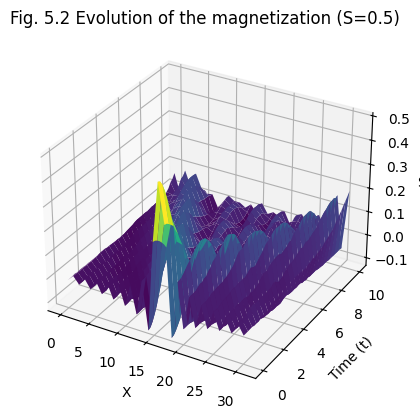

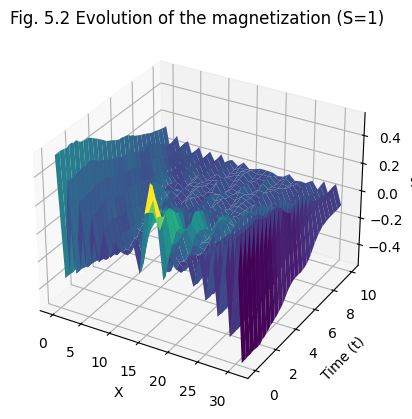

In [4]:
for d in d_list:
    Evolution_Sz = runs[d]['Evolution_Sz']
    # plt.plot(Evolution_Sz[-1,:])
    # plt.savefig('check')
    # quit()
    X = np.outer(np.linspace(0, N - 1, N), np.ones(time_slice + 1))
    T = np.outer(np.ones(N), np.linspace(0, tau*time_slice, time_slice + 1))
    SzMatrix = np.transpose(np.array(Evolution_Sz).real)
    fig = plt.figure()
    ax = plt.axes(projection='3d')
    ax.plot_surface(X, T, SzMatrix, cmap='viridis', edgecolor='none')
    ax.set_xlabel("X")
    ax.set_ylabel("Time (t)")
    ax.set_zlabel("Sz")
    ax.set_title('Fig. 5.2 Evolution of the magnetization (S=%g)' % ((d - 1) / 2))
    plt.show()
    plt.close()
    # fig.savefig("Evolution of the magnetization_tdvp")

    # np.save('data_sz_coor.npy',Evolution_Sz)


In [5]:
for d in d_list:
    print(d, runs[d]['Correlation_SpSm'].shape)


2 (51, 32)
3 (51, 32)


In [6]:
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.rcParams['font.family'] = 'Arial'
plt.rcParams['figure.figsize'] = [6,4]
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams["font.weight"] = "normal"
# plt.rcParams['xtick.fontfamily'] = 'bold'
# plt.rcParams['ytick.fontfamily'] = 'bold'
# plt.rcParams['font.sans-serif'] = 'bold'

## 4. Spectral function via Fourier transformation of time-dependence correlation function

In quantum mechanics, time and energy/frequency are Fourier conjugates. The spectral function, S($\omega$), mathematically represents the Fourier transform of a time-dependent correlation function, such as that by time-dependence Green's function (TDGF) as well as corresponding operators G(t) = $\langle \hat{O}(t) \hat{O}(0) \rangle = \int d\omega S(\omega) e^{-\tau \omega}   $ and TEBD:
$$
S(\omega,k) = \int\int dx dt e^{-ikx} e^{i\omega t} \langle S^-(x,t)S^+(\frac{L}{2},0) \rangle.
$$
They could be summarized as:
1. TDGF bases on analytical decoupling scheme but TEBD is purely numerical;
2. TDGF makes approximation on interaction but TEBD truncates the dimension and limits the entanglement;
3. TDGF is operator-based but TEBD is state-based;  
4. TDGF is highly effective for identifying specific interaction processes (like magnon-magnon scattering or Landau damping) but can miss complex, non-perturbative quantum effects. TEBD naturally captures all correlation effects—including multi-magnon continuum hybridization and spontaneous decay—without requiring a priori assumptions about which interaction terms are dominant.
5. TDGF provides a continuous frequency spectrum. Damping and spectral broadening are typically modeled by adding an explicit phenomenological imaginary part (a broadening factor $\eta$ or self-energy $\Sigma $ to the frequency. TEBD yields discrete frequency data based on the finite total time window of the simulation. The maximum propagation time bounds the spectral resolution (e.g., $\Delta \omega \approx \frac{2\pi}{T_{\text{max}}}$). To avoid truncation artifacts, the time series data usually requires windowing functions (such as gaussian window) or linear prediction methods.
6. They could be used together.

For calculating the time-depenence correlation, we perturbate the MPS by a local operator at initial time t=0:
$$
|\Psi(0)^{\alpha}\rangle = S^{\alpha}|Gs\rangle .
$$
Then we get the aother side by
$$
|\Psi(t)^{\beta}\rangle = e^{-i\hat{H}\tau}S^{\beta}|Gs\rangle .
$$
The correlation function is calculated by:
$$
\langle\Psi(t)^{\beta}|\Psi(0)^{\alpha}\rangle  .
$$

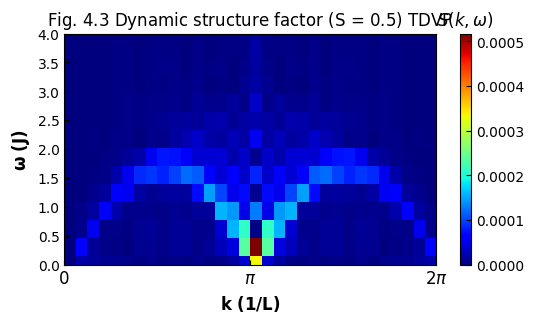

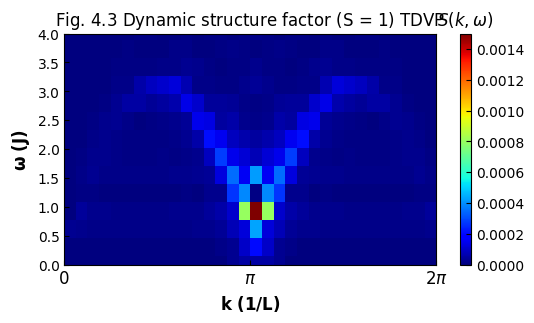

In [7]:
for d in d_list:
    Correlation_SpSm = runs[d]['Correlation_SpSm']
    Energy = runs[d]['Energy']
    phase_factor = [np.exp(Energy*1j*tau*i) for i in range(-time_slice,time_slice+1)]

    Correlation = np.transpose(np.array(Correlation_SpSm))
    Correlation = np.concatenate((np.flip(Correlation[:, 1:].conjugate(), axis=1), Correlation), axis=1)
    Correlation = Correlation @ np.diag(phase_factor)
    # eta = 2.0 / (tau * time_slice)
    # Correlation = Correlation * np.exp(-eta * np.abs(tau * np.arange(-time_slice, time_slice + 1)))

    Correlation = np.fft.ifftshift(Correlation, axes=1)
    Spec = np.absolute(np.fft.fft(np.fft.ifft(Correlation, axis=1), axis=0))
    Spec = Spec/np.size(Spec)

    NumOmega = Correlation.shape[1]
    domega = 2 * np.pi / (NumOmega * tau)
    n_pos = NumOmega // 2 + 1
    omega = domega * np.arange(n_pos)
    Spec = Spec[:, :n_pos]

    fig, ax = plt.subplots(figsize = (6,3))
    im = ax.imshow(abs(Spec).T, interpolation='none', cmap="jet",
                   origin='lower', aspect='auto',
                   extent=[0, 2 * np.pi, omega[0] - domega / 2, omega[-1] + domega / 2],
                   vmax=abs(Spec).max(), vmin=0)
    ax.set_ylim(0,4)
    # ax.set_ylim(0, omega[-1] + domega / 2)

    plt.xticks([0, np.pi, 2 * np.pi], ['0', r"$\pi$", r"$2\pi$"], fontsize=12)
    plt.xlabel(r'$\mathbf{k \ (1/L)}$', fontsize=12)
    plt.ylabel(r'$\mathbf{\omega \ (J)}$')
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_title(r'$S(k,\omega)$')

    ax.set_title(r'Fig. 4.3 Dynamic structure factor (S = $%g$) TDVP' % ((d-1)/2))
    plt.show()
    plt.close()
